--- РЕЗУЛЬТАТ (СРЕДНЕЕ И ДИСПЕРСИЯ) ---

Объект: Trees
  Grey: Среднее = 135.08, Дисперсия = 563.58
  Red: Среднее = 115.76, Дисперсия = 789.88
  Green: Среднее = 157.37, Дисперсия = 508.28
  Blue: Среднее = 69.06, Дисперсия = 457.32

Объект: Roads
  Grey: Среднее = 109.79, Дисперсия = 327.95
  Red: Среднее = 92.73, Дисперсия = 295.69
  Green: Среднее = 115.09, Дисперсия = 349.47
  Blue: Среднее = 127.20, Дисперсия = 335.40

Объект: Roofs
  Grey: Среднее = 129.38, Дисперсия = 52.58
  Red: Среднее = 139.17, Дисперсия = 59.79
  Green: Среднее = 125.58, Дисперсия = 55.11
  Blue: Среднее = 123.08, Дисперсия = 52.28


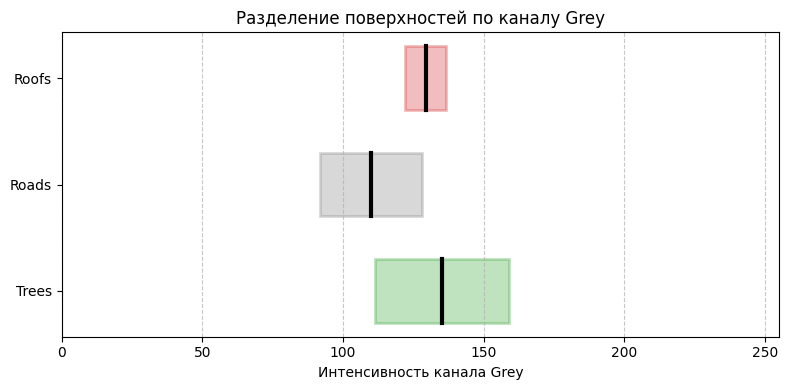

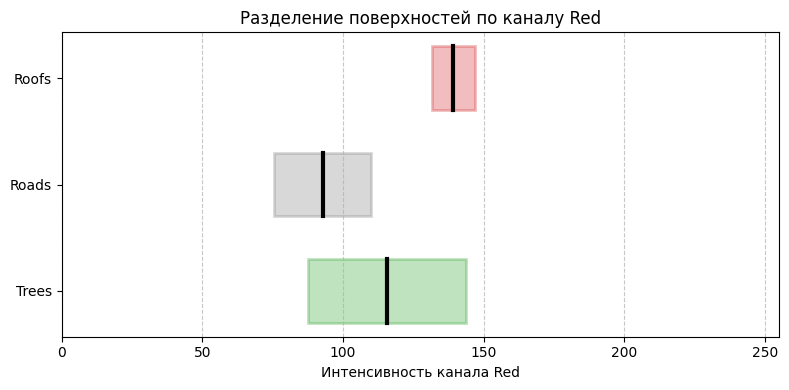

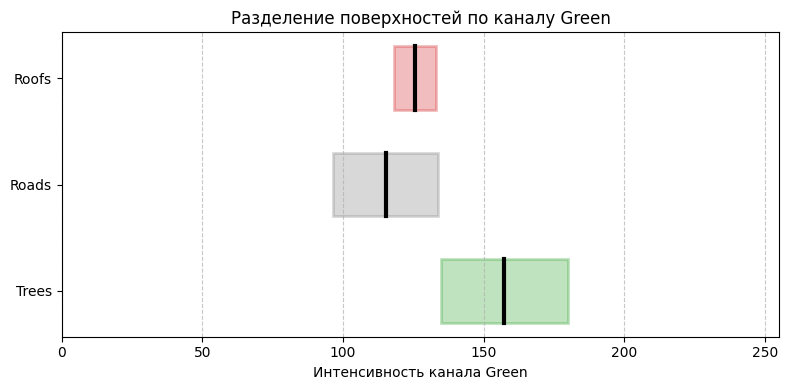

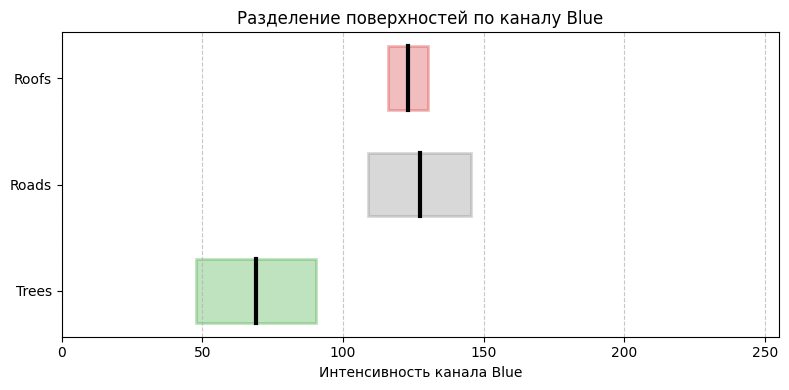

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

# --- ТВОИ ДАННЫЕ ИЗ ТАБЛИЦЫ ---
surfaces = ["Trees", "Roads", "Roofs"]
colors = ["Grey", "Red", "Green", "Blue"]

# L в твоей таблице — это Grey в коде
measurements = {
    "Trees": {
        "Grey": [136.82, 126.09, 125.70, 174.57, 112.21],
        "Red": [113.98, 101.09, 105.91, 164.25, 93.56],
        "Green": [162.68, 149.56, 149.14, 192.89, 132.58],
        "Blue": [60.65, 69.57, 54.52, 105.73, 54.84]
    },
    "Roads": {
        "Grey": [131.72, 107.99, 124.14, 96.27, 88.84],
        "Red": [115.68, 88.67, 104.42, 81.62, 73.25],
        "Green": [137.29, 114.11, 130.06, 100.57, 93.43],
        "Blue": [145.21, 126.91, 145.65, 112.51, 105.73]
    },
    "Roofs": {
        "Grey": [130.41, 134.88, 121.90, 137.68, 122.02],
        "Red": [144.69, 141.79, 129.96, 147.34, 132.08],
        "Green": [125.07, 132.06, 118.71, 134.12, 117.96],
        "Blue": [120.29, 131.03, 117.36, 130.61, 116.10]
    }
}

# Считаем среднее и дисперсию
means = {surf: {col: np.mean(measurements[surf][col]) for col in colors} for surf in surfaces}
stds = {surf: {col: np.std(measurements[surf][col], ddof=1) for col in colors} for surf in surfaces}

# Создаем папку для картинок
os.makedirs("./img", exist_ok=True)

surf_colors = ['#2ca02c', '#7f7f7f', '#d62728'] # Зеленый для деревьев, Серый для дорог, Красный для крыш
bar_height = 0.6

print("--- РЕЗУЛЬТАТ (СРЕДНЕЕ И ДИСПЕРСИЯ) ---")
for surf in surfaces:
    print(f"\nОбъект: {surf}")
    for col in colors:
        m = means[surf][col]
        v = np.var(measurements[surf][col], ddof=1)
        print(f"  {col}: Среднее = {m:.2f}, Дисперсия = {v:.2f}")

# Рисуем графики
for color in colors:
    fig, ax = plt.subplots(figsize=(8, 4))
    y_pos = np.arange(len(surfaces))

    for i, surf in enumerate(surfaces):
        mean_val = means[surf][color]
        std_val  = stds[surf][color]
        x_left   = mean_val - std_val
        x_right  = mean_val + std_val

        # Рисуем прямоугольник дисперсии
        rect = Rectangle(
            (x_left, i - bar_height/2),
            width=x_right - x_left,
            height=bar_height,
            facecolor=surf_colors[i],
            alpha=0.3,
            edgecolor=surf_colors[i],
            linewidth=2
        )
        ax.add_patch(rect)

        # Линия среднего
        ax.plot([mean_val, mean_val], [i - bar_height/2, i + bar_height/2],
                color='black', linewidth=3, label='Mean' if i==0 else "")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(surfaces)
    ax.set_xlabel(f'Интенсивность канала {color}')
    ax.set_title(f'Разделение поверхностей по каналу {color}')
    ax.set_xlim(0, 255)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"./img/chart_{color}.png")
    plt.show()
